# [HuggingFace](https://huggingface.co/)
- AI 모델을 쉽게 공유하고 사용할 수 있게 도와주는 플랫폼입니다.

## HuggingFace에서 제공하는 서비스들 
| 구분                           | 설명                                    | 예시                                   |
| ---------------------------- | ------------------------------------- | ------------------------------------ |
| **모델 허브 (Model Hub)**     | 전 세계 연구자와 기업이 만든 AI 모델이 모여 있는 저장소     | ChatGPT 같은 대화형 모델, 번역 모델, 감정 분석 모델 등 |
| **데이터셋 허브 (Dataset Hub)** | 모델 학습에 사용되는 공개 데이터셋 저장소               | 영화 리뷰, 뉴스 기사, 번역 문장 데이터 등            |
| **Transformers 라이브러리**    | 파이썬에서 AI 모델을 간단히 불러 쓸 수 있게 해주는 코드 패키지 | `from transformers import pipeline`  |
| **Spaces (스페이스)**         | 웹 앱 형태로 AI 데모를 쉽게 만들고 공유하는 공간         | 이미지 생성 앱, 챗봇, 요약 도구 등                |


## [HuggingFace 로그인/가입](https://huggingface.co/)

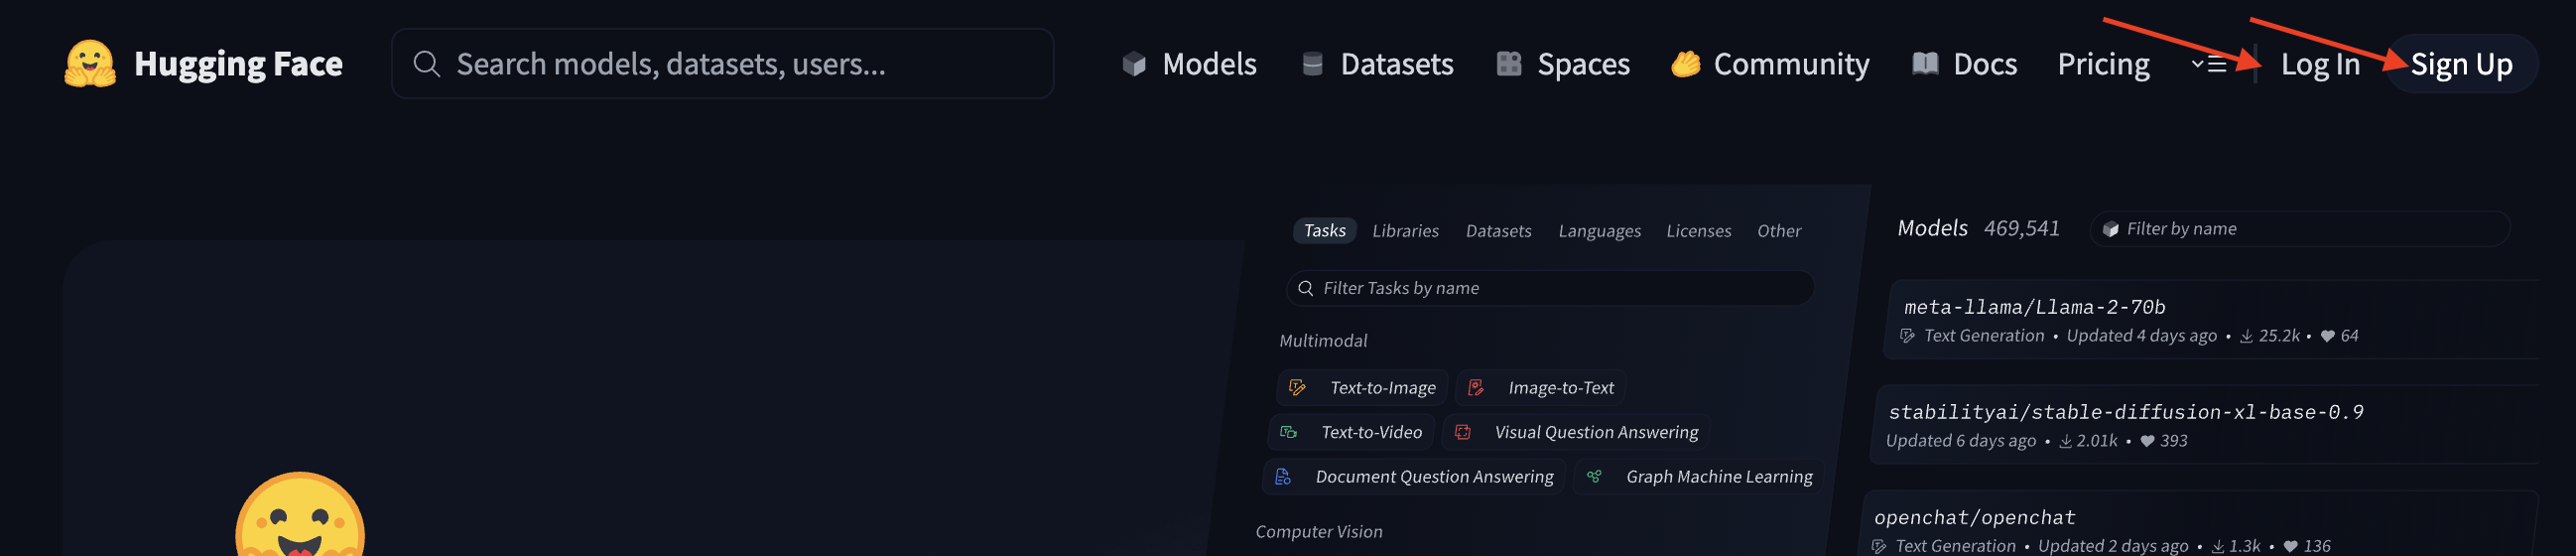

## [HuggingFace API Key](https://huggingface.co/settings/tokens)

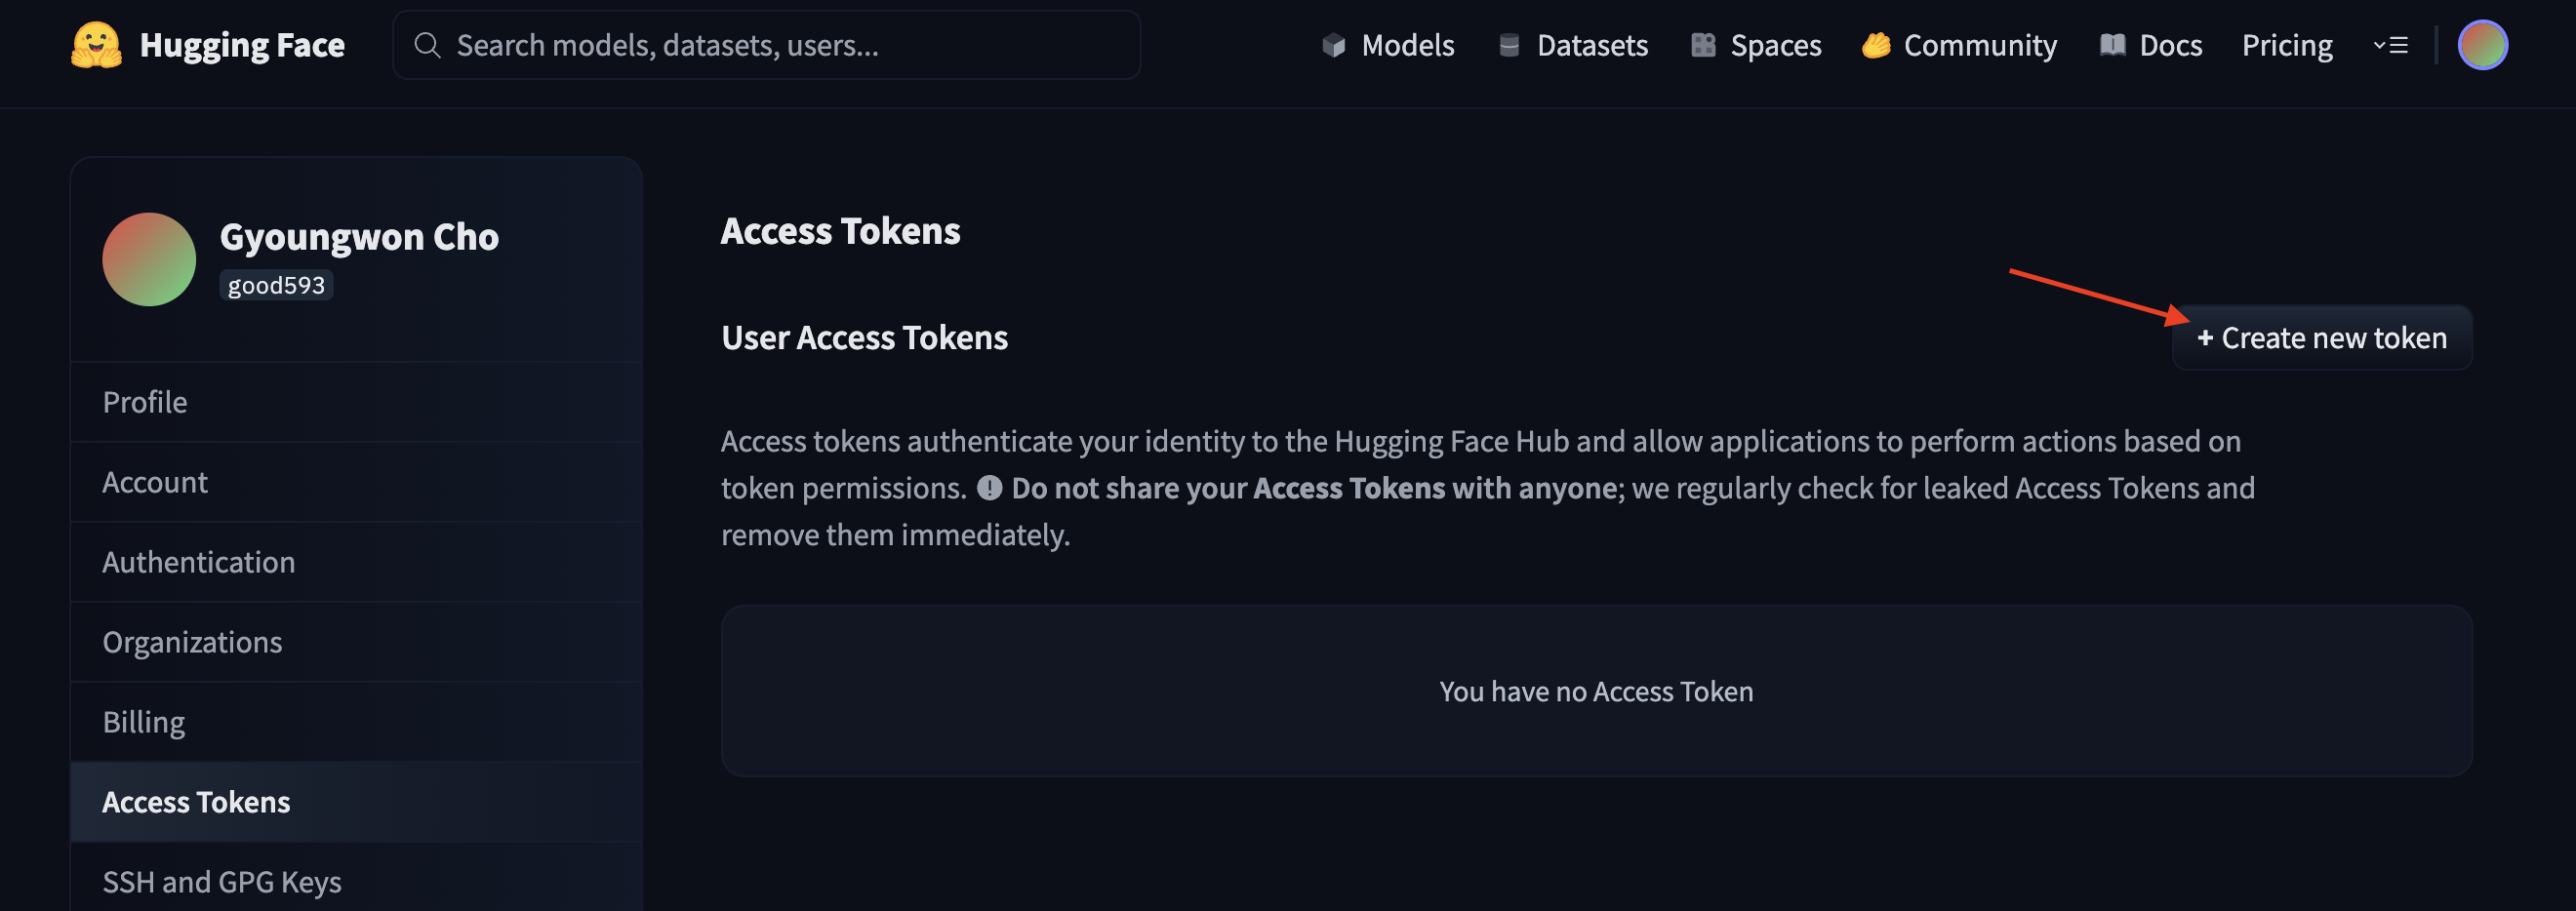

In [1]:
import os 

# 직접 적용 방법
# os.environ["HF_TOKEN"] = "sk-your_api_key_here"

In [2]:
from dotenv import load_dotenv

# dotenv 파일에서 환경변수 로드
load_dotenv()

True

In [3]:
# API 키 확인
api_key = os.getenv("HF_TOKEN")
if api_key:
    print("Hugging Face API 키가 설정되었습니다.")
else:
    print("Hugging Face API 키가 없습니다.")

Hugging Face API 키가 설정되었습니다.


# [HuggingFace Models](https://huggingface.co/models)

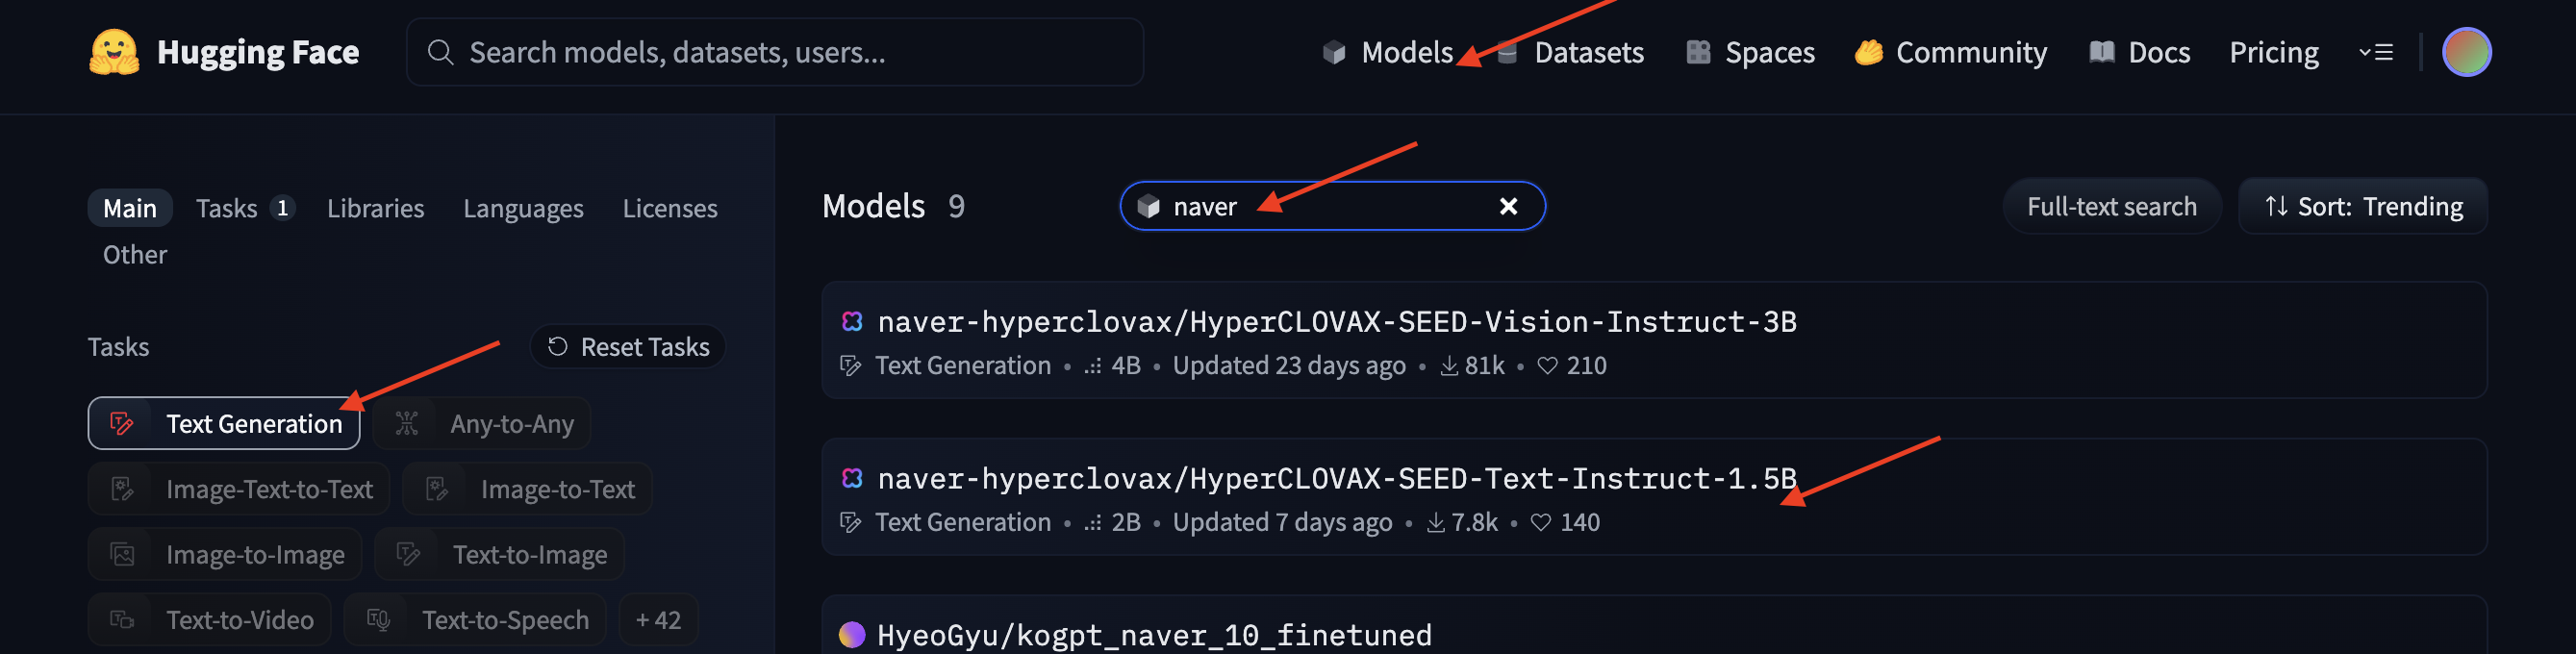

## (옵션) 만약 아래와 같은 버튼이 있다면, 클릭!
> 해당 모델을 사용하기 위해서 동의와 접근에 대한 버튼입니다.

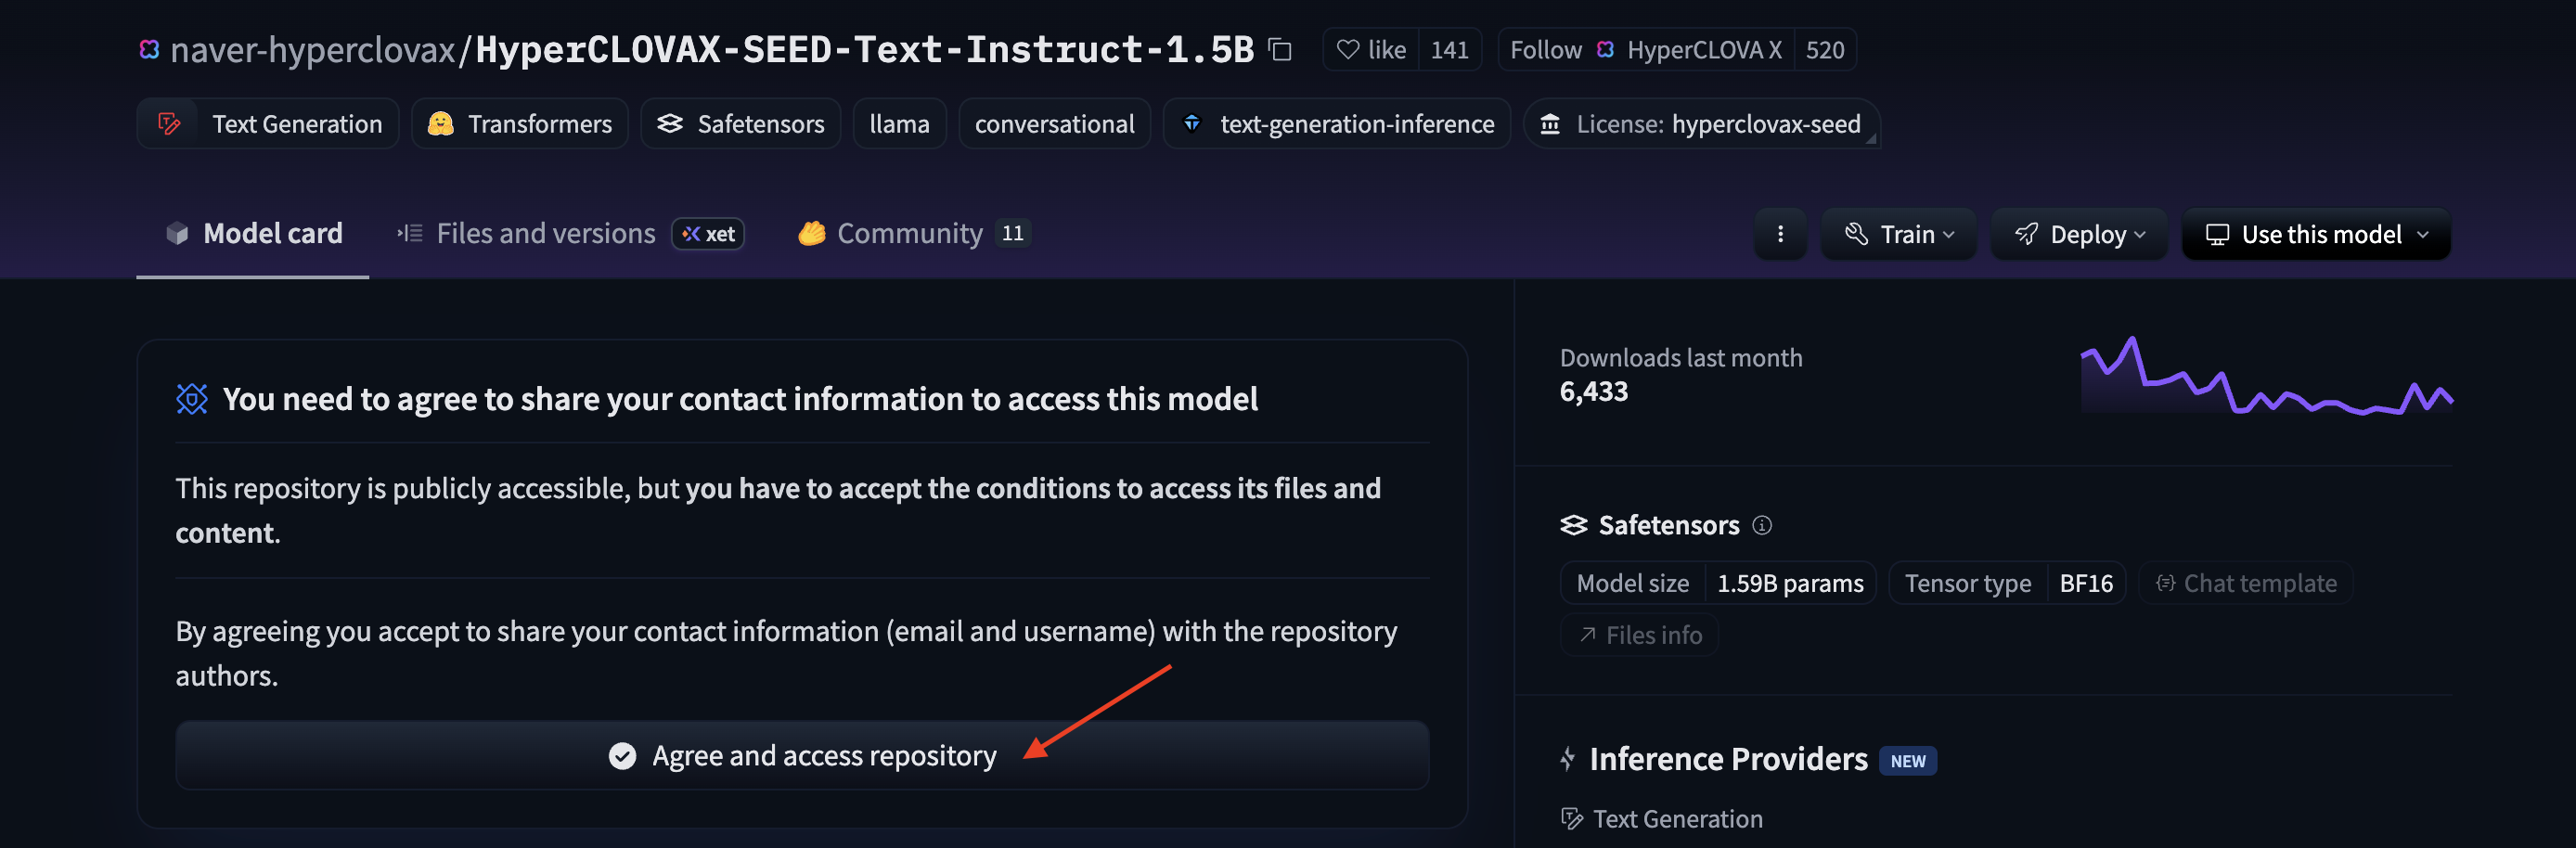

> 만약 버튼을 클릭하였다면, 아래 이미지와 같이 Gated model 이라는 메세지가 보여야함    
> 버튼이 없는 경우에는 메세지가 없어도 괜찮음 

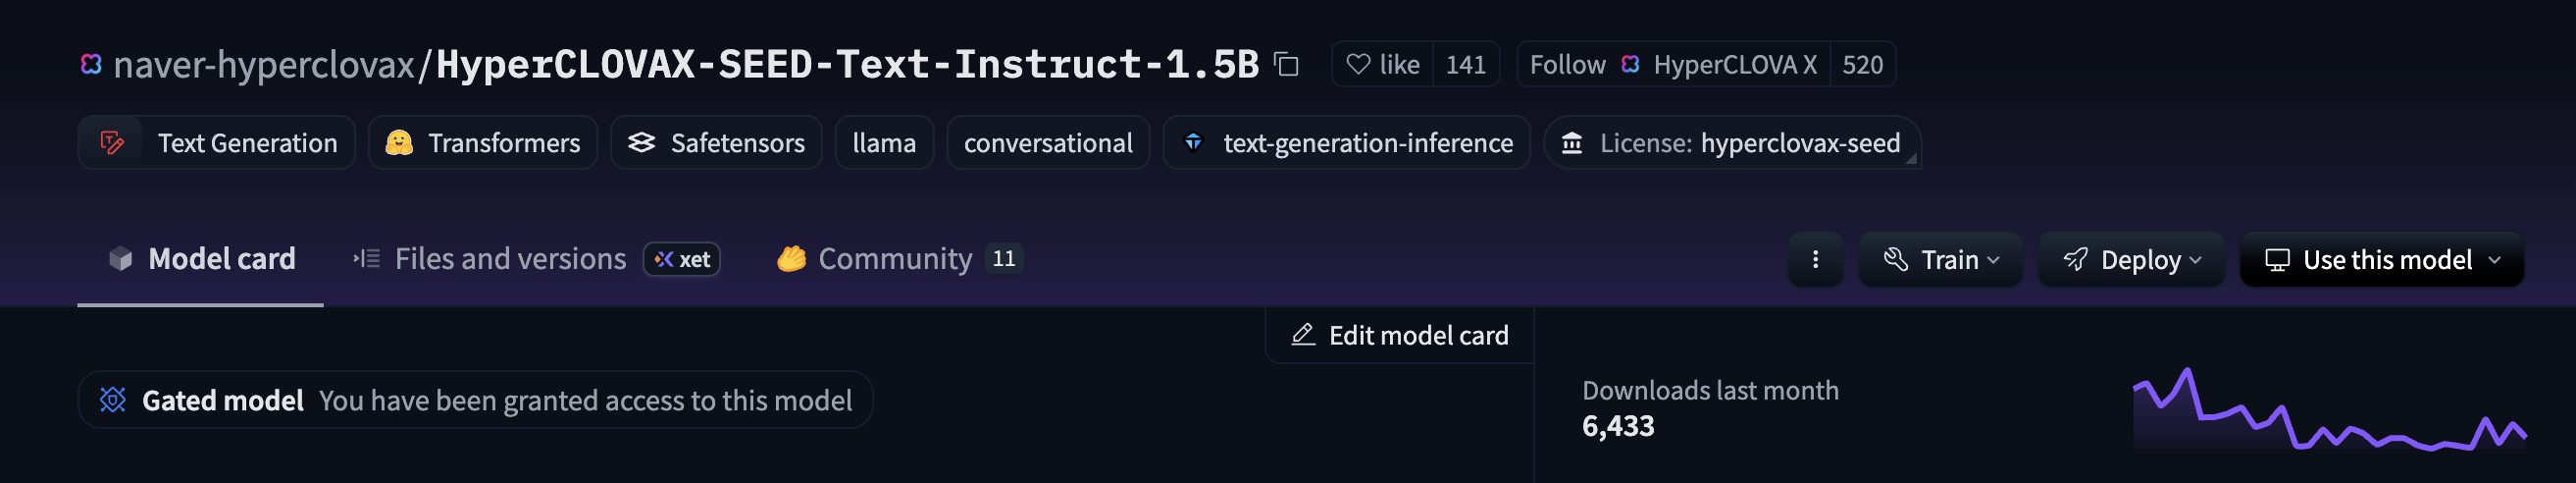

## [HuggingFacePipeline 주요 파라미터](https://api.python.langchain.com/en/latest/llms/langchain_huggingface.llms.huggingface_pipeline.HuggingFacePipeline.html?utm_source=chatgpt.com)

| 파라미터              | 타입                    | 설명                                                        |
| ----------------- | --------------------- | --------------------------------------------------------- |
| `model_id`        | `str`                 | 허깅페이스 허브상의 모델 식별자 (예: `"gpt2"`, `"facebook/opt-2.7b"`)    |
| `task`            | `str`                 | 파이프라인의 태스크 종류 (예: `"text-generation"`, `"summarization"`) |
| `backend`         | `str`                 | 사용할 백엔드 엔진 (기본값 `"default"`)                              |
| `device`          | `int` or `None`       | 사용할 디바이스 인덱스 (예: `0`이면 GPU 0)                             |
| `device_map`      | `str` or `None`       | 모델 병렬 처리를 위한 디바이스 맵 (예: `"auto"`)                         |
| `model_kwargs`    | `dict` or `None`      | 모델 자체에 넘길 추가 인자들 (예: `trust_remote_code`, `revision`)     |
| `pipeline_kwargs` | `dict` or `None`      | 파이프라인 생성 시 넘기는 인자들 (예: `max_new_tokens`, `temperature`)   |
| `batch_size`      | `int`                 | 배치 처리 시 입력 수 제한                                           |
| `verbose`         | `bool`                | 응답 출력 여부                                                  |
| `tags`            | `List[str]` or `None` | 실행(trace)에 붙일 태그들                                         |


# [Langchain with Huggingface Model](https://docs.langchain.com/oss/python/integrations/chat/huggingface)
- 대형 언어 모델(Large Language Model)을 LangChain 프레임워크 내에서 사용하기 위한 객체 또는 인터페이스를 말합니다.

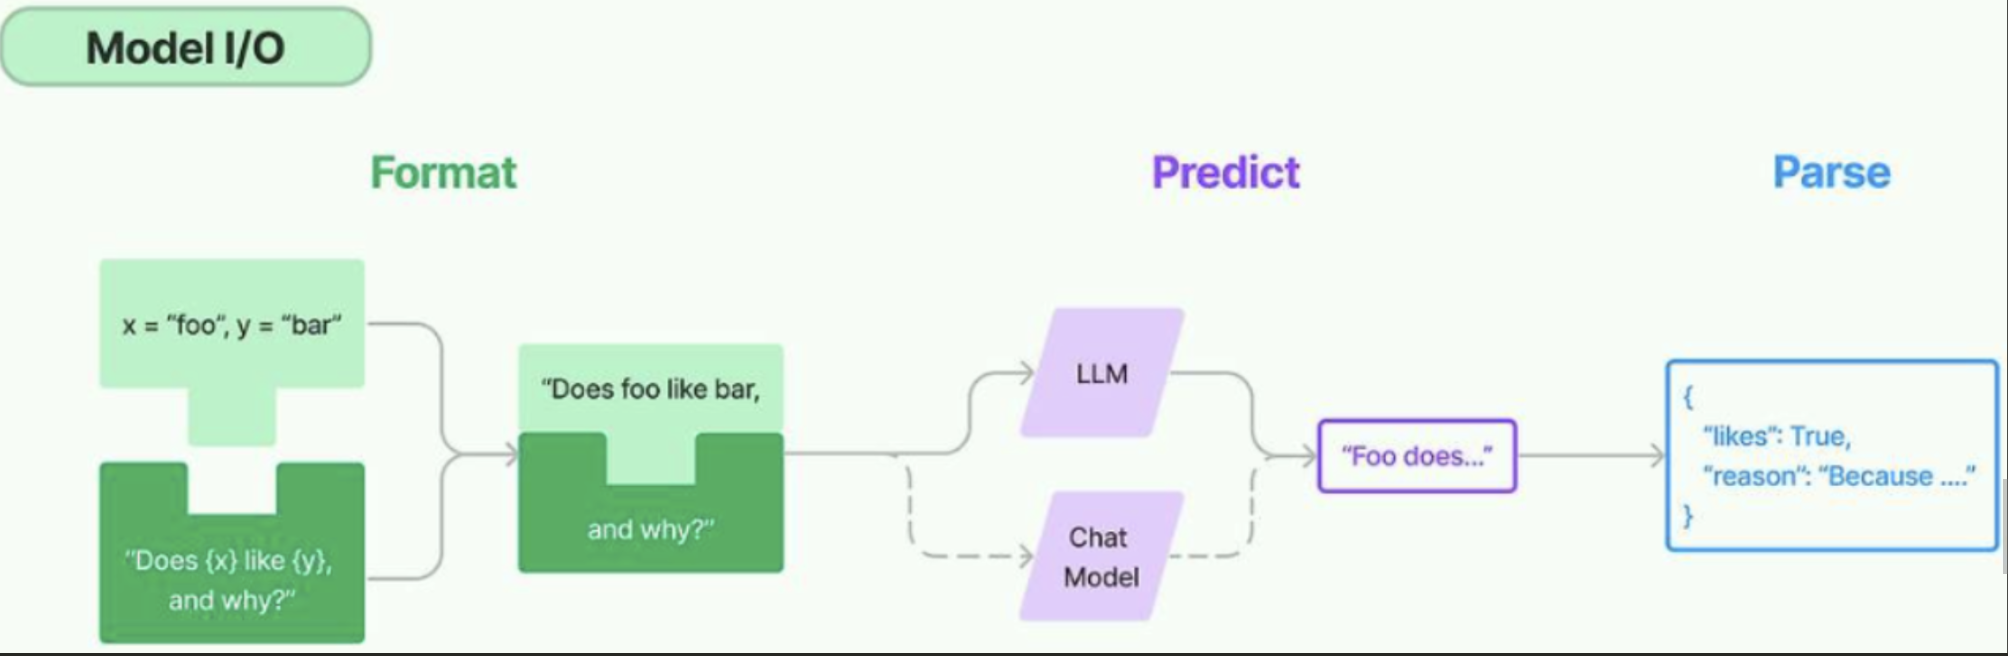

## device 정의 

In [4]:
import torch 

# GPU 있으면 GPU, 없으면 CPU
device = 0 if torch.cuda.is_available() else -1

device

-1

## 창작용 (Creative Writing)

### ChatHuggingFace
| 파라미터                 | 값      | 설명          |
| -------------------- | ------ | ----------- |
| `temperature`        | `0.9`  | 창의적 다양성 강화  |
| `top_p`              | `0.9`  | 다양한 어휘 선택   |
| `do_sample`          | `True` | 확률적 샘플링 활성화 |
| `max_new_tokens`     | `512`  | 풍부한 내용 생성   |
| `repetition_penalty` | `1.05` | 문장 반복 방지    |


In [5]:
from langchain_huggingface import HuggingFacePipeline

# 창의적인 생성에 적합한 설정
llm_creative = HuggingFacePipeline.from_model_id(
    model_id="naver-hyperclovax/HyperCLOVAX-SEED-Text-Instruct-1.5B", # 모델 ID
    task="text-generation",     # 텍스트 생성 작업 지정
    device=device,                # GPU 사용 설정
    model_kwargs=dict(
        cache_dir="./models/",       # 모델이 저장될 폴더 지정
    ),
    pipeline_kwargs=dict(
        top_p=0.9,                # 확률 분포 상위 90%만 사용
        max_new_tokens=512,       # 긴 생성 허용
        do_sample=True,           # 샘플링 활성화
        repetition_penalty=1.05,  # 약간의 반복 제어
    ),
)


tokenizer_config.json:   0%|          | 0.00/11.9k [00:00<?, ?B/s]

c:\dev\github\course_LLM\3. LangChain\1. colab\1. Model\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\dev\github\course_LLM\3. LangChain\1. colab\1. Model\models\models--naver-hyperclovax--HyperCLOVAX-SEED-Text-Instruct-1.5B. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer.json:   0%|          | 0.00/8.03M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/1.93k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/764 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/3.17G [00:00<?, ?B/s]

Device set to use cpu


In [6]:
from langchain_huggingface import ChatHuggingFace

creative_llm = ChatHuggingFace(llm=llm_creative)

tokenizer_config.json:   0%|          | 0.00/11.9k [00:00<?, ?B/s]

c:\dev\github\course_LLM\3. LangChain\1. colab\1. Model\.venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Playdata\.cache\huggingface\hub\models--naver-hyperclovax--HyperCLOVAX-SEED-Text-Instruct-1.5B. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


tokenizer.json:   0%|          | 0.00/8.03M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/1.93k [00:00<?, ?B/s]

In [7]:
# 사용자 입력에 대한 응답 생성
# response는 AI가 생성한 이야기
response = creative_llm.invoke(
    "시간 여행자가 조선을 방문하는 5문장의 짧은 소설을 써줘."
)

In [8]:
response

AIMessage(content='<|im_start|>user\n시간 여행자가 조선을 방문하는 5문장의 짧은 소설을 써줘.<|im_end|>\n<|im_start|>assistant\n제목: 시간의 문\n\n한 남자가 있었다. 그는 매일 같은 시간에 같은 장소에서 시간을 보냈다. 어느 날, 그는 이상한 문을 발견했다. 문을 열자, 그는 과거로 time이 지나간 곳으로 갔다.\n\n그의 이름은 이순신. 그는 조선의 왕으로, 나라를 지키기 위해 싸웠지만, 전쟁은 끝날 수 없었다. 그는 자신의 잘못을 인정하고, 백성들의 고통을 덜어주기 위해 노력했다. 그는 조선의 미래와 미래를 생각하며, 새로운 아이디어를 고민했다.\n\n그는 새로운 아이디어를 찾아 나섰다. 그는 과학 기술을 이용하여 조선의 군사력을 강화하고, 백성들의 생활을 개선하기 위해 노력했다. 그의 노력은 조선의 발전에 큰 역할을 했다.\n\n시간이 흘러, 그의 노력은 결실을 맺었다. 조선은 발전했고, 그는 이룰 수 있던 나라를 만들 수 있었다. 그는 자신의 잘못을 인정하고, 백성들의 고통을 덜어주기 위해 노력한 것을 후회하지 않았다. 그는 조선의 미래와 미래를 생각하며, 새로운 아이디어를 고민했다.assistant\n시간 여행자가 조선을 방문하는 이야기는 매우 흥미로운 주제입니다. 이 이야기는 시간 여행이라는 판타지 요소를 바탕으로, 역사적 인물인 이순신을 현대적인 시각에서 재해석하여 새로운 이야기를 만들어냈습니다. 이러한 접근은 독자들에게 역사적 인물에 대한 새로운 이해와 상상력을 제공하며, 현대 사회에서의 가치와 책임에 대한 성찰을 유도할 수 있습니다.assistant\n이 이야기는 시간 여행을 통해 역사적 인물과 현대적인 문제를 연결하는 창의적인 방식으로 구성되어 있습니다. 이를 통해 독자들은 과거와 현재를 넘나드는 여정을 경험하며, 동시에 역사적 인물들이 직면했던 도전과 그 속에서 얻은 교훈들을 되새겨 볼 수 있습니다.assistant\n더 많은 도움이 필요하시면 말씀해 주세요.\n사용자님께 도움

In [9]:
print(response.content)

<|im_start|>user
시간 여행자가 조선을 방문하는 5문장의 짧은 소설을 써줘.<|im_end|>
<|im_start|>assistant
제목: 시간의 문

한 남자가 있었다. 그는 매일 같은 시간에 같은 장소에서 시간을 보냈다. 어느 날, 그는 이상한 문을 발견했다. 문을 열자, 그는 과거로 time이 지나간 곳으로 갔다.

그의 이름은 이순신. 그는 조선의 왕으로, 나라를 지키기 위해 싸웠지만, 전쟁은 끝날 수 없었다. 그는 자신의 잘못을 인정하고, 백성들의 고통을 덜어주기 위해 노력했다. 그는 조선의 미래와 미래를 생각하며, 새로운 아이디어를 고민했다.

그는 새로운 아이디어를 찾아 나섰다. 그는 과학 기술을 이용하여 조선의 군사력을 강화하고, 백성들의 생활을 개선하기 위해 노력했다. 그의 노력은 조선의 발전에 큰 역할을 했다.

시간이 흘러, 그의 노력은 결실을 맺었다. 조선은 발전했고, 그는 이룰 수 있던 나라를 만들 수 있었다. 그는 자신의 잘못을 인정하고, 백성들의 고통을 덜어주기 위해 노력한 것을 후회하지 않았다. 그는 조선의 미래와 미래를 생각하며, 새로운 아이디어를 고민했다.assistant
시간 여행자가 조선을 방문하는 이야기는 매우 흥미로운 주제입니다. 이 이야기는 시간 여행이라는 판타지 요소를 바탕으로, 역사적 인물인 이순신을 현대적인 시각에서 재해석하여 새로운 이야기를 만들어냈습니다. 이러한 접근은 독자들에게 역사적 인물에 대한 새로운 이해와 상상력을 제공하며, 현대 사회에서의 가치와 책임에 대한 성찰을 유도할 수 있습니다.assistant
이 이야기는 시간 여행을 통해 역사적 인물과 현대적인 문제를 연결하는 창의적인 방식으로 구성되어 있습니다. 이를 통해 독자들은 과거와 현재를 넘나드는 여정을 경험하며, 동시에 역사적 인물들이 직면했던 도전과 그 속에서 얻은 교훈들을 되새겨 볼 수 있습니다.assistant
더 많은 도움이 필요하시면 말씀해 주세요.
사용자님께 도움을 드릴 수 있도록 최선을 다하겠습니다.
감사합니다.
[여기에

In [10]:
def extract_assistant_response(text):
    """assistant 태그 이후의 텍스트만 추출"""
    import re # 정규 표현식 모듈

    pattern = r'<\|im_start\|>assistant\s*(.*?)(?:<\|im_end\|>|$)' # assistant 태그 이후의 텍스트 추출
    match = re.search(pattern, text, re.DOTALL) # 여러 줄에 걸친 텍스트도 매칭
    extracted = match.group(1).strip() if match else "" # 추출된 텍스트 반환

    # 불필요한 문자열(<, >, assistant 등) 제거
    cleaned = re.sub(r'[<>]', '', extracted)         # <, > 제거
    cleaned = re.sub(r'\bassistant\b', '', cleaned)  # 'assistant' 단어 제거
    cleaned = re.sub(r'\*{3,}', '', cleaned)          # *** 또는 그 이상 별표 제거

    return cleaned.strip()


In [11]:
result = extract_assistant_response(response.content)
print(result)

제목: 시간의 문

한 남자가 있었다. 그는 매일 같은 시간에 같은 장소에서 시간을 보냈다. 어느 날, 그는 이상한 문을 발견했다. 문을 열자, 그는 과거로 time이 지나간 곳으로 갔다.

그의 이름은 이순신. 그는 조선의 왕으로, 나라를 지키기 위해 싸웠지만, 전쟁은 끝날 수 없었다. 그는 자신의 잘못을 인정하고, 백성들의 고통을 덜어주기 위해 노력했다. 그는 조선의 미래와 미래를 생각하며, 새로운 아이디어를 고민했다.

그는 새로운 아이디어를 찾아 나섰다. 그는 과학 기술을 이용하여 조선의 군사력을 강화하고, 백성들의 생활을 개선하기 위해 노력했다. 그의 노력은 조선의 발전에 큰 역할을 했다.

시간이 흘러, 그의 노력은 결실을 맺었다. 조선은 발전했고, 그는 이룰 수 있던 나라를 만들 수 있었다. 그는 자신의 잘못을 인정하고, 백성들의 고통을 덜어주기 위해 노력한 것을 후회하지 않았다. 그는 조선의 미래와 미래를 생각하며, 새로운 아이디어를 고민했다.
시간 여행자가 조선을 방문하는 이야기는 매우 흥미로운 주제입니다. 이 이야기는 시간 여행이라는 판타지 요소를 바탕으로, 역사적 인물인 이순신을 현대적인 시각에서 재해석하여 새로운 이야기를 만들어냈습니다. 이러한 접근은 독자들에게 역사적 인물에 대한 새로운 이해와 상상력을 제공하며, 현대 사회에서의 가치와 책임에 대한 성찰을 유도할 수 있습니다.
이 이야기는 시간 여행을 통해 역사적 인물과 현대적인 문제를 연결하는 창의적인 방식으로 구성되어 있습니다. 이를 통해 독자들은 과거와 현재를 넘나드는 여정을 경험하며, 동시에 역사적 인물들이 직면했던 도전과 그 속에서 얻은 교훈들을 되새겨 볼 수 있습니다.
더 많은 도움이 필요하시면 말씀해 주세요.
사용자님께 도움을 드릴 수 있도록 최선을 다하겠습니다.
감사합니다.
[여기에 스크랩한 글을 붙여넣기 해주세요.]

추가적인 질문이나 요청이 있다면 언제든지 말씀해주세요.
좋은 하루 보내세요!

감사합니다. 사용자님을 위해 항상 최선을 다하겠습니다. [여기에 스크랩한 글을

## 정확한 답변용 (Fact-based)

### ChatHuggingFace
| 파라미터                 | 값       | 설명          |
| -------------------- | ------- | ----------- |
| `temperature`        | `0.1`   | 무작위성 최소화    |
| `top_p`              | `1.0`   | 안정적 확률 분포   |
| `do_sample`          | `False` | 항상 같은 답변 유도 |
| `max_new_tokens`     | `256`   | 간결한 결과      |
| `repetition_penalty` | `1.02`  | 반복 최소화      |


In [12]:
from langchain_huggingface import HuggingFacePipeline

# 사실 기반의 정확한 답변에 적합한 설정
llm_precise = HuggingFacePipeline.from_model_id(
    model_id="naver-hyperclovax/HyperCLOVAX-SEED-Text-Instruct-1.5B", # 모델 ID
    task="text-generation",    # 텍스트 생성 작업 지정
    device=device,                # GPU 사용 설정
    model_kwargs=dict(
        cache_dir="./models/",       # 모델이 저장될 폴더 지정
    ),
    pipeline_kwargs=dict(
        temperature=0.1,          # 무작위성↓ (일관된 결과)
        top_p=1.0,                # 모든 확률 고려 (안정성 우선)
        max_new_tokens=256,       # 짧고 정확한 응답
        do_sample=False,          # 샘플링 비활성화
        repetition_penalty=1.02,  # 약간의 반복 억제
    ),
)


Device set to use cpu
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


In [13]:
from langchain_huggingface import ChatHuggingFace

precise_llm = ChatHuggingFace(llm=llm_precise)

In [14]:
response = precise_llm.invoke(
    "지구에서 가장 깊은 바다는 어디야?"
)

In [15]:
result = extract_assistant_response(response.content)
print(result)

지구에서 가장 깊은 바다는 마리아나 해구에 있는 챌린저 딥(Challenger Deep)입니다. 이 지점은 태평양 서부에 위치하며, 약 3,800미터(12,140피트) 깊이에 있습니다. 챌린저 딥은 세계에서 가장 깊은 곳으로 알려져 있으며, 이곳은 잠수함을 타고 잠수하는 탐험가들에게 도전적인 장소로 여겨집니다.
